<a href="https://colab.research.google.com/github/MO230101/Copolymer-lipid-interaction-study_ver.2/blob/main/%E3%80%87TD_NMR_graph_for_NC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

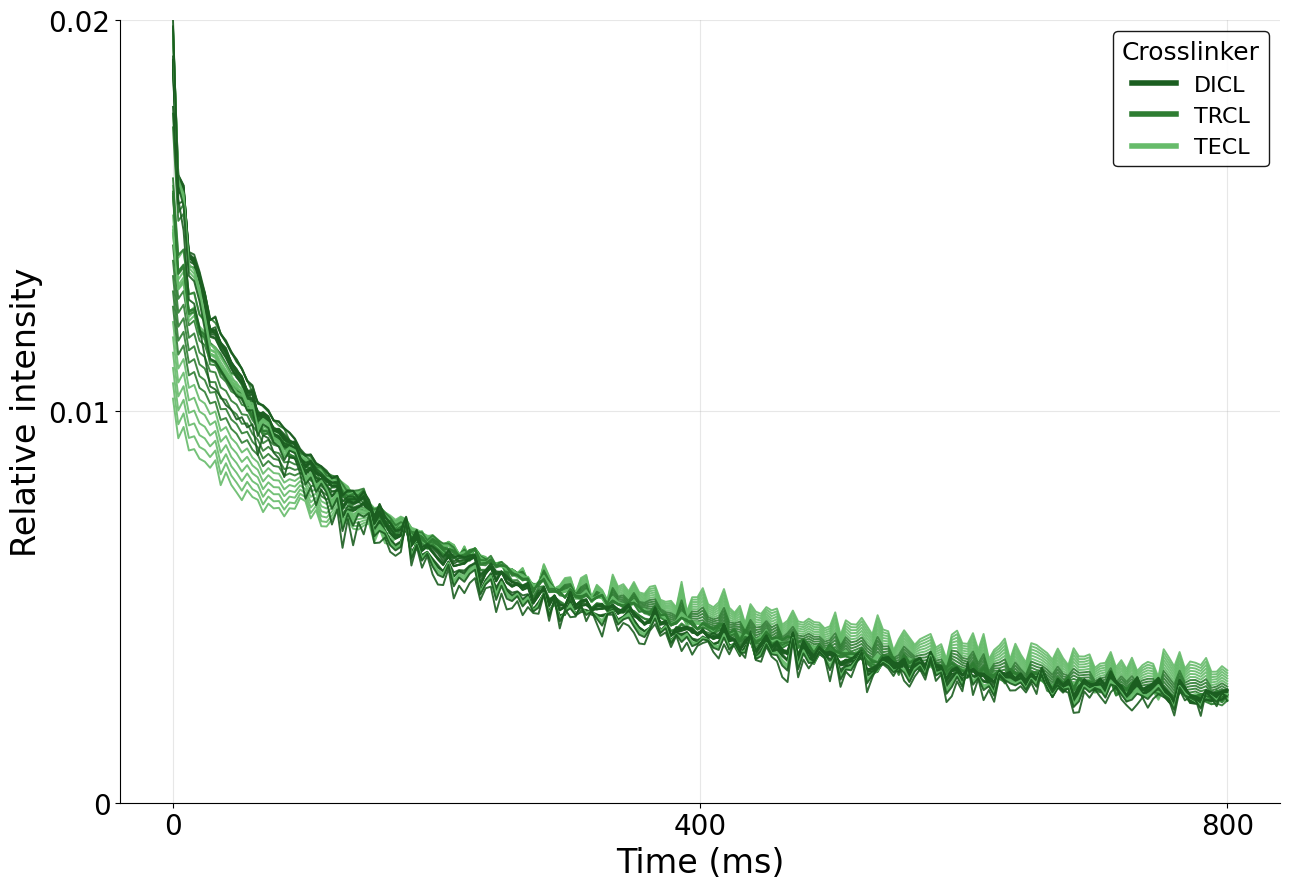

Saved: /content/AddD2O_CPMG_T2_curves_fixed_y0.png
Saved: /content/AddD2O_CPMG_T2_curves_fixed_y0.pdf


In [15]:
# ============================================================
# Google Colab COMPLETE CODE
# 2D plot of T2 relaxation curves
# - colored by crosslinker using code2 color scheme
# - larger X/Y axis fonts
# - X ticks = 0, 400, 800 ms
# - Y minimum fixed to 0
# - Y tick label "0" instead of "0.00"
# - legend inside plot frame
# - AddD2O_CPMG
# ============================================================

!pip -q install numpy pandas matplotlib

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ------------------------------------------------------------
# 1. Input CSV
# ------------------------------------------------------------
CSV_PATH = "AddD2O_CPMG_T2_Relative_Intensity_smoothed_44copolymers.csv"

# ------------------------------------------------------------
# 2. Load data
# ------------------------------------------------------------
df = pd.read_csv(CSV_PATH)

name_col = df.columns[0]

df[name_col] = df[name_col].astype(str)
df = df.drop_duplicates(subset=name_col).reset_index(drop=True)

sample_names = df[name_col].tolist()

# ------------------------------------------------------------
# 3. Time axis
# ------------------------------------------------------------
n = df.shape[1] - 1

time_ms = np.linspace(0, 0.4, n)

Y = (
    df.iloc[:, 1:]
    .apply(pd.to_numeric, errors="coerce")
    .to_numpy(dtype=float)
)

Y = np.nan_to_num(
    Y,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

Y[Y < 0] = 0.0

# ------------------------------------------------------------
# 4. Crosslinker extraction
# ------------------------------------------------------------
CROSSLINKER_ORDER = ["DICL", "TRCL", "TECL"]

def get_crosslinker(sample_name: str) -> str:

    s = str(sample_name)
    s = re.sub(r'_\d+$', '', s)

    parts = s.split("_")

    for key in CROSSLINKER_ORDER:
        if key in parts:
            return key

    return "OTHER"

crosslinkers = [get_crosslinker(s) for s in sample_names]

# ------------------------------------------------------------
# 5. Color map from code2
# ------------------------------------------------------------
color_map = {
    "DICL":  "#1B5E20",
    "TRCL":  "#2E7D32",
    "TECL":  "#66BB6A",
    "OTHER": "#999999",
}

# ------------------------------------------------------------
# 6. Plot settings
# ------------------------------------------------------------
LINE_WIDTH = 1.4
ALPHA = 0.9

AXIS_LABEL_SIZE = 24
TICK_LABEL_SIZE = 20

LEGEND_FONT_SIZE = 16
LEGEND_TITLE_SIZE = 18

fig, ax = plt.subplots(figsize=(13, 9))

# ------------------------------------------------------------
# 7. Plot all curves
# ------------------------------------------------------------
for i, sample in enumerate(sample_names):

    cl = crosslinkers[i]

    c = color_map.get(
        cl,
        color_map["OTHER"]
    )

    ax.plot(
        time_ms,
        Y[i],
        lw=LINE_WIDTH,
        alpha=ALPHA,
        color=c
    )

# ------------------------------------------------------------
# 8. Axis labels
# ------------------------------------------------------------
ax.set_xlabel(
    "Time (ms)",
    fontsize=AXIS_LABEL_SIZE
)

ax.set_ylabel(
    "Relative intensity",
    fontsize=AXIS_LABEL_SIZE
)

# ------------------------------------------------------------
# 9. X-axis ticks
# ------------------------------------------------------------
ax.set_xticks([0.0, 0.2, 0.4])

ax.set_xticklabels(
    ["0", "400", "800"],
    fontsize=TICK_LABEL_SIZE
)

# ------------------------------------------------------------
# 10. Y-axis settings
# ------------------------------------------------------------
y_min = 0.0
y_max = np.nanmax(Y)

ax.set_ylim(0.0, y_max)

y_ticks = [
    0.0,
    y_max / 2,
    y_max
]

ax.set_yticks(y_ticks)

# ---- first label is "0" ----
ax.set_yticklabels(
    [
        "0",
        f"{y_max/2:.2f}",
        f"{y_max:.2f}"
    ],
    fontsize=TICK_LABEL_SIZE
)

# ------------------------------------------------------------
# 11. Tick parameters
# ------------------------------------------------------------
ax.tick_params(
    axis="both",
    labelsize=TICK_LABEL_SIZE
)

# ------------------------------------------------------------
# 12. Style
# ------------------------------------------------------------
ax.grid(True, alpha=0.3)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ------------------------------------------------------------
# 13. Legend inside plot frame
# ------------------------------------------------------------
legend_handles = [
    Line2D(
        [0],
        [0],
        color=color_map["DICL"],
        lw=4,
        label="DICL"
    ),

    Line2D(
        [0],
        [0],
        color=color_map["TRCL"],
        lw=4,
        label="TRCL"
    ),

    Line2D(
        [0],
        [0],
        color=color_map["TECL"],
        lw=4,
        label="TECL"
    ),
]

ax.legend(
    handles=legend_handles,
    title="Crosslinker",
    loc="upper right",
    fontsize=LEGEND_FONT_SIZE,
    title_fontsize=LEGEND_TITLE_SIZE,
    frameon=True,
    framealpha=0.9,
    edgecolor="black"
)

# ------------------------------------------------------------
# 14. Save
# ------------------------------------------------------------
plt.tight_layout()

png_path = "/content/AddD2O_CPMG_T2_curves_fixed_y0.png"

pdf_path = "/content/AddD2O_CPMG_T2_curves_fixed_y0.pdf"

plt.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    pdf_path,
    bbox_inches="tight"
)

plt.show()

print("Saved:", png_path)
print("Saved:", pdf_path)

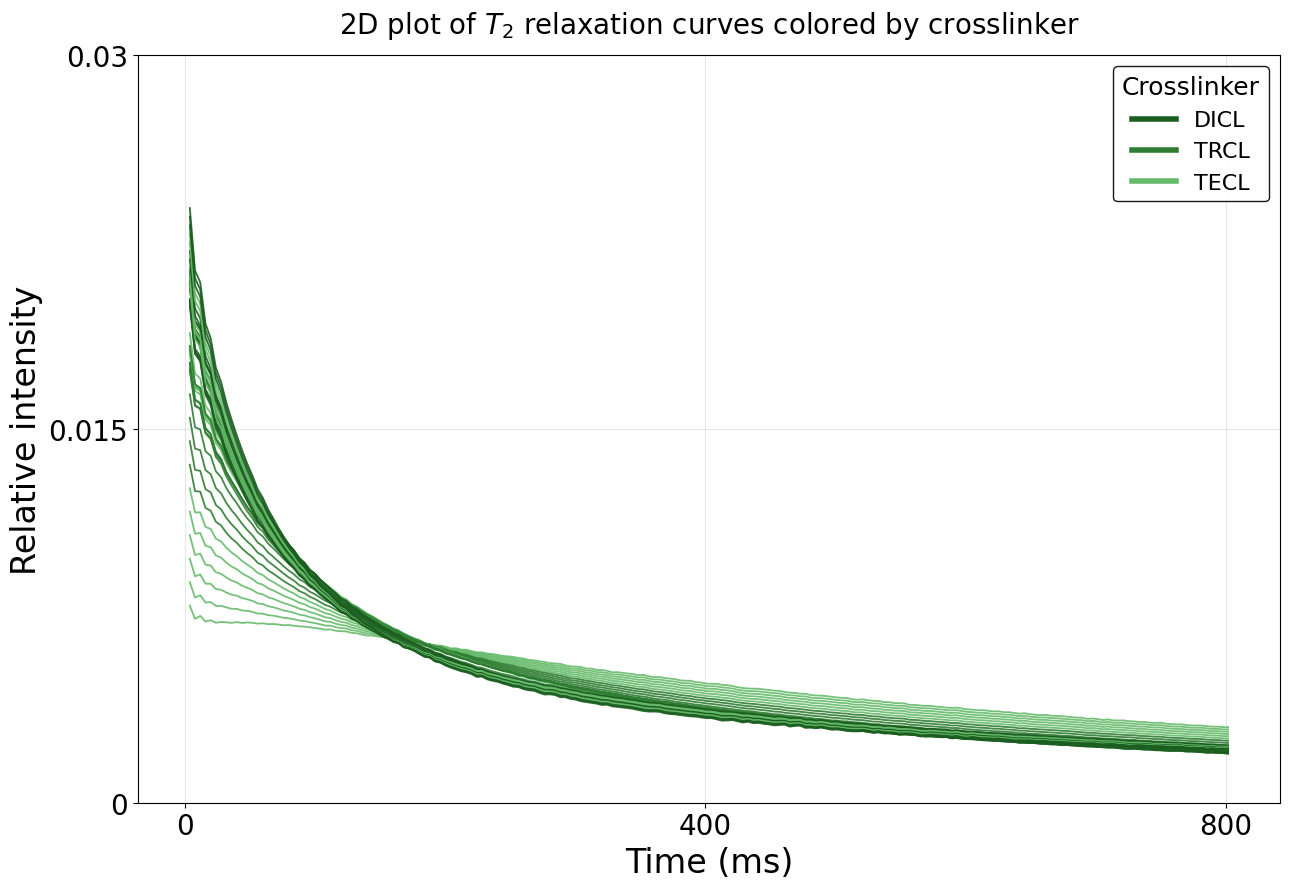

Saved: /content/Addwater_CPMG_T2_curves_fixed_ticks.png
Saved: /content/Addwater_CPMG_T2_curves_fixed_ticks.pdf


In [14]:
# ============================================================
# Google Colab COMPLETE CODE
# Addwater_CPMG T2 relaxation curves
# - colored by crosslinker using code2 color scheme
# - larger X/Y axis fonts
# - X ticks = 0, 400, 800 ms
# - Y ticks = 0, 0.015, 0.03
# - small margin below minimum Y
# - legend inside plot frame
# - Addwater_CPMG
# ============================================================

!pip -q install numpy pandas matplotlib

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ------------------------------------------------------------
# 1. Input CSV
# ------------------------------------------------------------
CSV_PATH = "Addwater_CPMG_T2_Relative_Intensity_smoothed_44copolymers.csv"

# ------------------------------------------------------------
# 2. Load data
# ------------------------------------------------------------
df = pd.read_csv(CSV_PATH)

name_col = df.columns[0]
sample_names_raw = df[name_col].astype(str).tolist()

t2_cols = df.columns[1:]

t2_vals = np.array([
    float(str(c).replace("ms", "").replace("MS", "").strip())
    for c in t2_cols
], dtype=float)

Y = df[t2_cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)

# ------------------------------------------------------------
# 3. Helper functions
# ------------------------------------------------------------
CROSSLINKER_ORDER = ["DICL", "TRCL", "TECL"]

def get_crosslinker(sample_name: str) -> str:

    s = str(sample_name)
    s = re.sub(r'_\d+$', '', s)

    parts = s.split("_")

    for key in CROSSLINKER_ORDER:
        if key in parts:
            return key

    return "OTHER"

def make_unique_names(names):

    total_counts = {}

    for n in names:
        total_counts[n] = total_counts.get(n, 0) + 1

    seen_counts = {}
    out = []

    for n in names:

        seen_counts[n] = seen_counts.get(n, 0) + 1

        if total_counts[n] == 1:
            out.append(n)
        else:
            out.append(f"{n}_{seen_counts[n]}")

    return out

sample_names = make_unique_names(sample_names_raw)
crosslinkers = [get_crosslinker(s) for s in sample_names]

# ------------------------------------------------------------
# 4. Clean data
# ------------------------------------------------------------
mask = np.isfinite(t2_vals) & (t2_vals > 0)

x = t2_vals[mask]
Y = Y[:, mask]

Y = np.nan_to_num(Y, nan=0.0, posinf=0.0, neginf=0.0)
Y[Y < 0] = 0.0

# ------------------------------------------------------------
# 5. Color map from code2
# ------------------------------------------------------------
color_map = {
    "DICL":  "#1B5E20",
    "TRCL":  "#2E7D32",
    "TECL":  "#66BB6A",
    "OTHER": "#999999",
}

# ------------------------------------------------------------
# 6. Plot settings
# ------------------------------------------------------------
USE_LOG_X = False

LINE_WIDTH = 1.3
ALPHA = 0.9

AXIS_LABEL_SIZE = 24
TICK_LABEL_SIZE = 20
TITLE_SIZE = 20

fig, ax = plt.subplots(figsize=(13, 9))

# ------------------------------------------------------------
# 7. Plot all curves
# ------------------------------------------------------------
for i, sample in enumerate(sample_names):

    cl = crosslinkers[i]
    c = color_map.get(cl, color_map["OTHER"])

    ax.plot(
        x,
        Y[i],
        lw=LINE_WIDTH,
        alpha=ALPHA,
        color=c
    )

# ------------------------------------------------------------
# 8. Axis settings
# ------------------------------------------------------------
if USE_LOG_X:
    ax.set_xscale("log")

ax.set_xlabel(
    "Time (ms)",
    fontsize=AXIS_LABEL_SIZE
)

ax.set_ylabel(
    "Relative intensity",
    fontsize=AXIS_LABEL_SIZE
)

ax.set_title(
    r"2D plot of $T_2$ relaxation curves colored by crosslinker",
    fontsize=TITLE_SIZE,
    pad=16
)

# ------------------------------------------------------------
# 9. X-axis ticks
# ------------------------------------------------------------
ax.set_xticks([0, 400, 800])

ax.set_xticklabels(
    ["0", "400", "800"],
    fontsize=TICK_LABEL_SIZE
)

# ------------------------------------------------------------
# 10. Y-axis ticks and limits
# ------------------------------------------------------------
# 0以下の余白を削除
ax.set_ylim(0.0, 0.03)

ax.set_yticks([0.0, 0.015, 0.03])

ax.set_yticklabels(
    ["0", "0.015", "0.03"],
    fontsize=TICK_LABEL_SIZE
)

# ------------------------------------------------------------
# 11. Tick parameters
# ------------------------------------------------------------
ax.tick_params(
    axis="both",
    labelsize=TICK_LABEL_SIZE
)

# ------------------------------------------------------------
# 12. Style
# ------------------------------------------------------------
ax.grid(True, alpha=0.3)

# ------------------------------------------------------------
# 13. Legend inside plot frame
# ------------------------------------------------------------
legend_handles = [
    Line2D([0], [0], color=color_map["DICL"], lw=4, label="DICL"),
    Line2D([0], [0], color=color_map["TRCL"], lw=4, label="TRCL"),
    Line2D([0], [0], color=color_map["TECL"], lw=4, label="TECL"),
]

ax.legend(
    handles=legend_handles,
    title="Crosslinker",
    loc="upper right",
    fontsize=16,
    title_fontsize=18,
    frameon=True,
    framealpha=0.9,
    edgecolor="black"
)

# ------------------------------------------------------------
# 14. Save
# ------------------------------------------------------------
plt.tight_layout()

png_path = "/content/Addwater_CPMG_T2_curves_fixed_ticks.png"
pdf_path = "/content/Addwater_CPMG_T2_curves_fixed_ticks.pdf"

plt.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    pdf_path,
    bbox_inches="tight"
)

plt.show()

print("Saved:", png_path)
print("Saved:", pdf_path)

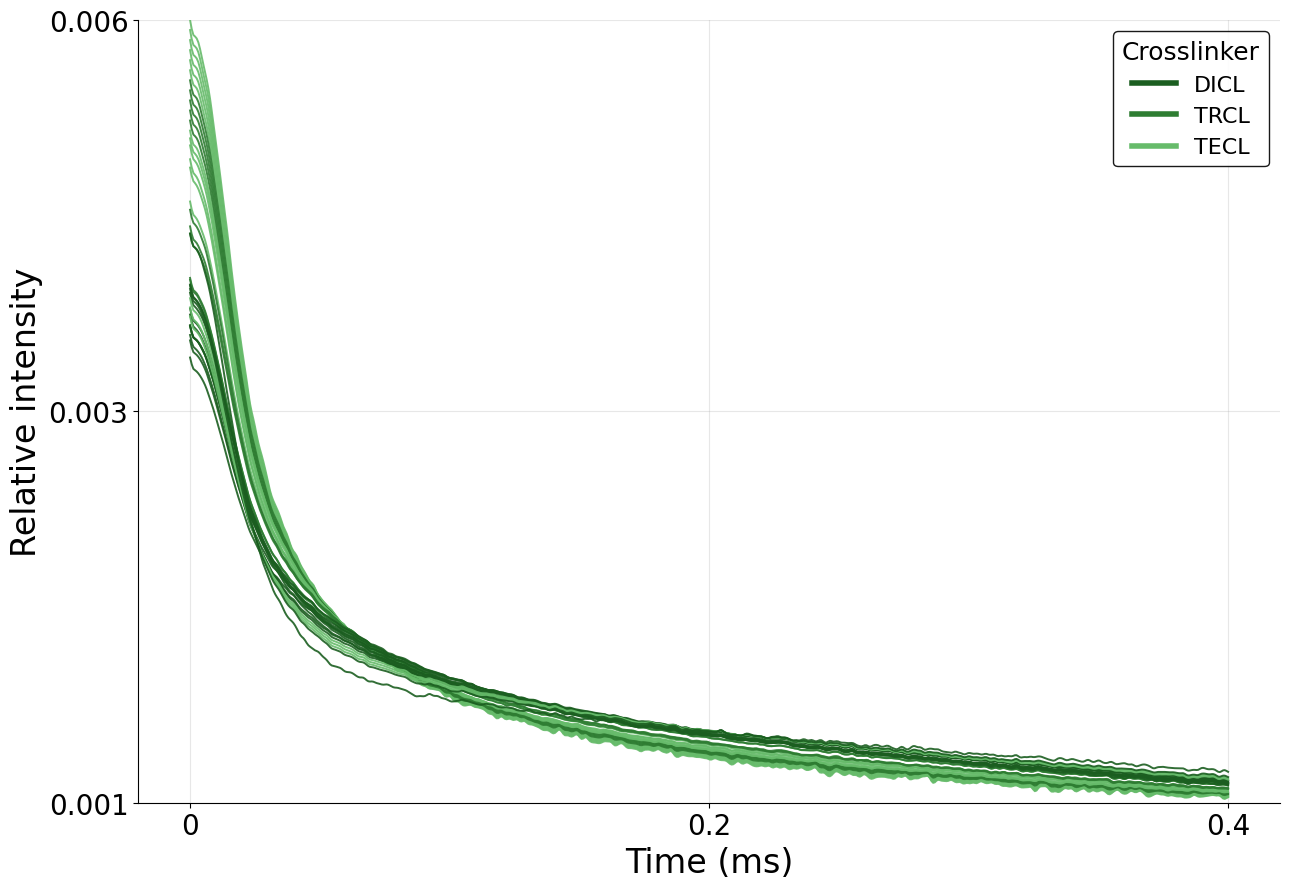

Saved: /content/AddD2O_MSE_T2_curves_crosslinker_colors_ymin_0001.png
Saved: /content/AddD2O_MSE_T2_curves_crosslinker_colors_ymin_0001.pdf


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from matplotlib.lines import Line2D

CSV_MSE = "AddD2O_MSE_T2_Relative_Intensity_smoothed_44copolymers2.csv"

# =========================
# Load
# =========================
df = pd.read_csv(CSV_MSE)

name_col = df.columns[0]
df[name_col] = df[name_col].astype(str)
df = df.drop_duplicates(subset=name_col).reset_index(drop=True)

# =========================
# Time axis
# =========================
n = df.shape[1] - 1
time_ms = np.linspace(0, 0.4, n)

# =========================
# Data
# =========================
Y = df.iloc[:, 1:].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)

Y = np.nan_to_num(
    Y,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

Y[Y < 0] = 0.0

# =========================
# Crosslinker color map
# =========================
CROSSLINKER_ORDER = ["DICL", "TRCL", "TECL"]

color_map = {
    "DICL":  "#1B5E20",
    "TRCL":  "#2E7D32",
    "TECL":  "#66BB6A",
    "OTHER": "#999999",
}

def get_crosslinker(sample_name: str) -> str:

    s = str(sample_name)
    s = re.sub(r'_\d+$', '', s)

    parts = s.split("_")

    for key in CROSSLINKER_ORDER:
        if key in parts:
            return key

    return "OTHER"

# =========================
# Plot
# =========================
fig, ax = plt.subplots(figsize=(13, 9))

for i, row in df.iterrows():

    name = row.iloc[0]
    y = Y[i]

    cl = get_crosslinker(name)

    c = color_map.get(
        cl,
        color_map["OTHER"]
    )

    ax.plot(
        time_ms,
        y,
        lw=1.4,
        alpha=0.9,
        color=c
    )

# =========================
# Axis labels
# =========================
ax.set_xlabel("Time (ms)", fontsize=24)
ax.set_ylabel("Relative intensity", fontsize=24)

# =========================
# X-axis settings
# =========================
ax.set_xticks([0.0, 0.2, 0.4])

ax.set_xticklabels(
    ["0", "0.2", "0.4"],
    fontsize=20
)

# =========================
# Y-axis settings
# =========================
y_min = 0.001
y_max = np.nanmax(Y)

ax.set_ylim(y_min, y_max)

y_ticks = [
    y_min,
    (y_min + y_max) / 2,
    y_max
]

ax.set_yticks(y_ticks)

ax.set_yticklabels(
    [
        "0.001",
        f"{(y_min + y_max) / 2:.3f}",
        f"{y_max:.3f}"
    ],
    fontsize=20
)

# =========================
# Style
# =========================
ax.grid(True, alpha=0.3)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# =========================
# Legend inside plot frame
# =========================
legend_handles = [
    Line2D([0], [0], color=color_map["DICL"], lw=4, label="DICL"),
    Line2D([0], [0], color=color_map["TRCL"], lw=4, label="TRCL"),
    Line2D([0], [0], color=color_map["TECL"], lw=4, label="TECL"),
]

ax.legend(
    handles=legend_handles,
    title="Crosslinker",
    loc="upper right",
    fontsize=16,
    title_fontsize=18,
    frameon=True,
    framealpha=0.9,
    edgecolor="black"
)

# =========================
# Save
# =========================
plt.tight_layout()

png_path = "/content/AddD2O_MSE_T2_curves_crosslinker_colors_ymin_0001.png"

pdf_path = "/content/AddD2O_MSE_T2_curves_crosslinker_colors_ymin_0001.pdf"

plt.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    pdf_path,
    bbox_inches="tight"
)

plt.show()

print("Saved:", png_path)
print("Saved:", pdf_path)

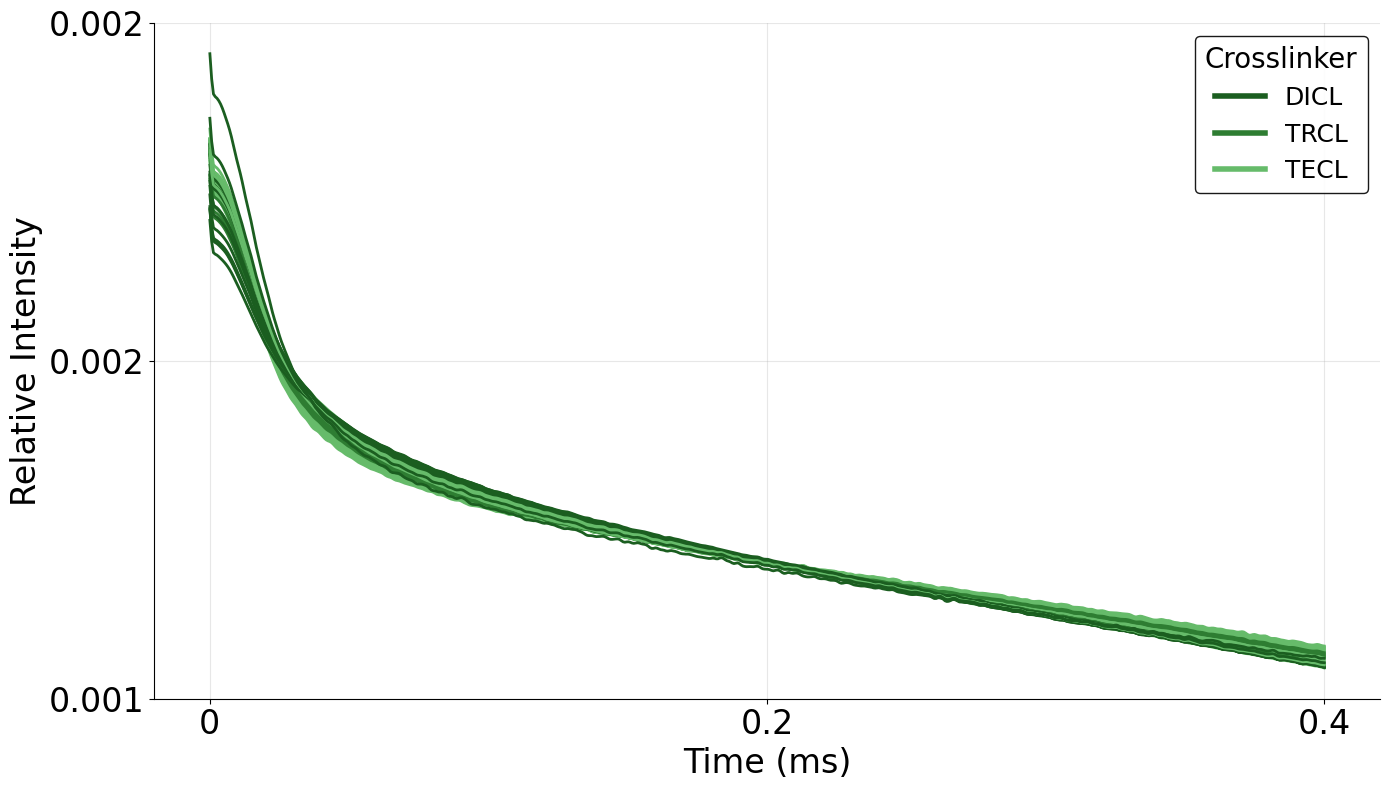

Saved: /content/Addwater_MSE_allcopolymers_crosslinker_legend_wide.png
Saved: /content/Addwater_MSE_allcopolymers_crosslinker_legend_wide.pdf


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from matplotlib.lines import Line2D

CSV_MSE = "Addwater_MSE_T2_Relative_Intensity_smoothed_44copolymers2.csv"

# =========================
# Load
# =========================
df = pd.read_csv(CSV_MSE)

name_col = df.columns[0]

df[name_col] = df[name_col].astype(str)
df = df.drop_duplicates(subset=name_col).reset_index(drop=True)

# =========================
# Time axis
# =========================
n = df.shape[1] - 1
time_ms = np.linspace(0, 0.4, n)

# =========================
# Crosslinker colors
# =========================
CROSSLINKER_ORDER = ["DICL", "TRCL", "TECL"]

color_map = {
    "DICL": "#1B5E20",
    "TRCL": "#2E7D32",
    "TECL": "#66BB6A",
    "OTHER": "#999999",
}

def get_crosslinker(label: str) -> str:

    s = str(label)
    s = re.sub(r'_\d+$', '', s)

    parts = s.split("_")

    for cl in CROSSLINKER_ORDER:
        if cl in parts:
            return cl

    return "OTHER"

# =========================
# Plot
# =========================
# 横長比率へ変更
fig, ax = plt.subplots(figsize=(14, 8))

# 縦長化防止
ax.set_aspect("auto")

for _, row in df.iterrows():

    name = row.iloc[0]
    y = row.iloc[1:].values.astype(float)

    cl = get_crosslinker(name)

    color = color_map.get(
        cl,
        color_map["OTHER"]
    )

    ax.plot(
        time_ms,
        y,
        lw=2,
        color=color
    )

# =========================
# Axis labels
# =========================
ax.set_xlabel(
    "Time (ms)",
    fontsize=24
)

ax.set_ylabel(
    "Relative Intensity",
    fontsize=24
)

# =========================
# Axis ticks
# =========================
ax.set_xticks([0.0, 0.2, 0.4])

ax.set_xticklabels(
    ["0", "0.2", "0.4"],
    fontsize=24
)

ymin, ymax = ax.get_ylim()

yt = [
    ymin,
    (ymin + ymax) / 2,
    ymax
]

ax.set_yticks(yt)

ax.set_yticklabels(
    [f"{v:.3f}" for v in yt],
    fontsize=24
)

# =========================
# Style
# =========================
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(True, alpha=0.3)

# =========================
# Crosslinker legend
# =========================
legend_handles = [
    Line2D(
        [0],
        [0],
        color=color_map["DICL"],
        lw=4,
        label="DICL"
    ),

    Line2D(
        [0],
        [0],
        color=color_map["TRCL"],
        lw=4,
        label="TRCL"
    ),

    Line2D(
        [0],
        [0],
        color=color_map["TECL"],
        lw=4,
        label="TECL"
    ),
]

ax.legend(
    handles=legend_handles,
    title="Crosslinker",
    loc="upper right",
    fontsize=18,
    title_fontsize=20,
    frameon=True,
    framealpha=0.9,
    edgecolor="black"
)

# =========================
# Layout
# =========================
plt.tight_layout()

# =========================
# Save
# =========================
png_path = "/content/Addwater_MSE_allcopolymers_crosslinker_legend_wide.png"

pdf_path = "/content/Addwater_MSE_allcopolymers_crosslinker_legend_wide.pdf"

plt.savefig(
    png_path,
    dpi=300
)

plt.savefig(
    pdf_path
)

plt.show()

print("Saved:", png_path)
print("Saved:", pdf_path)

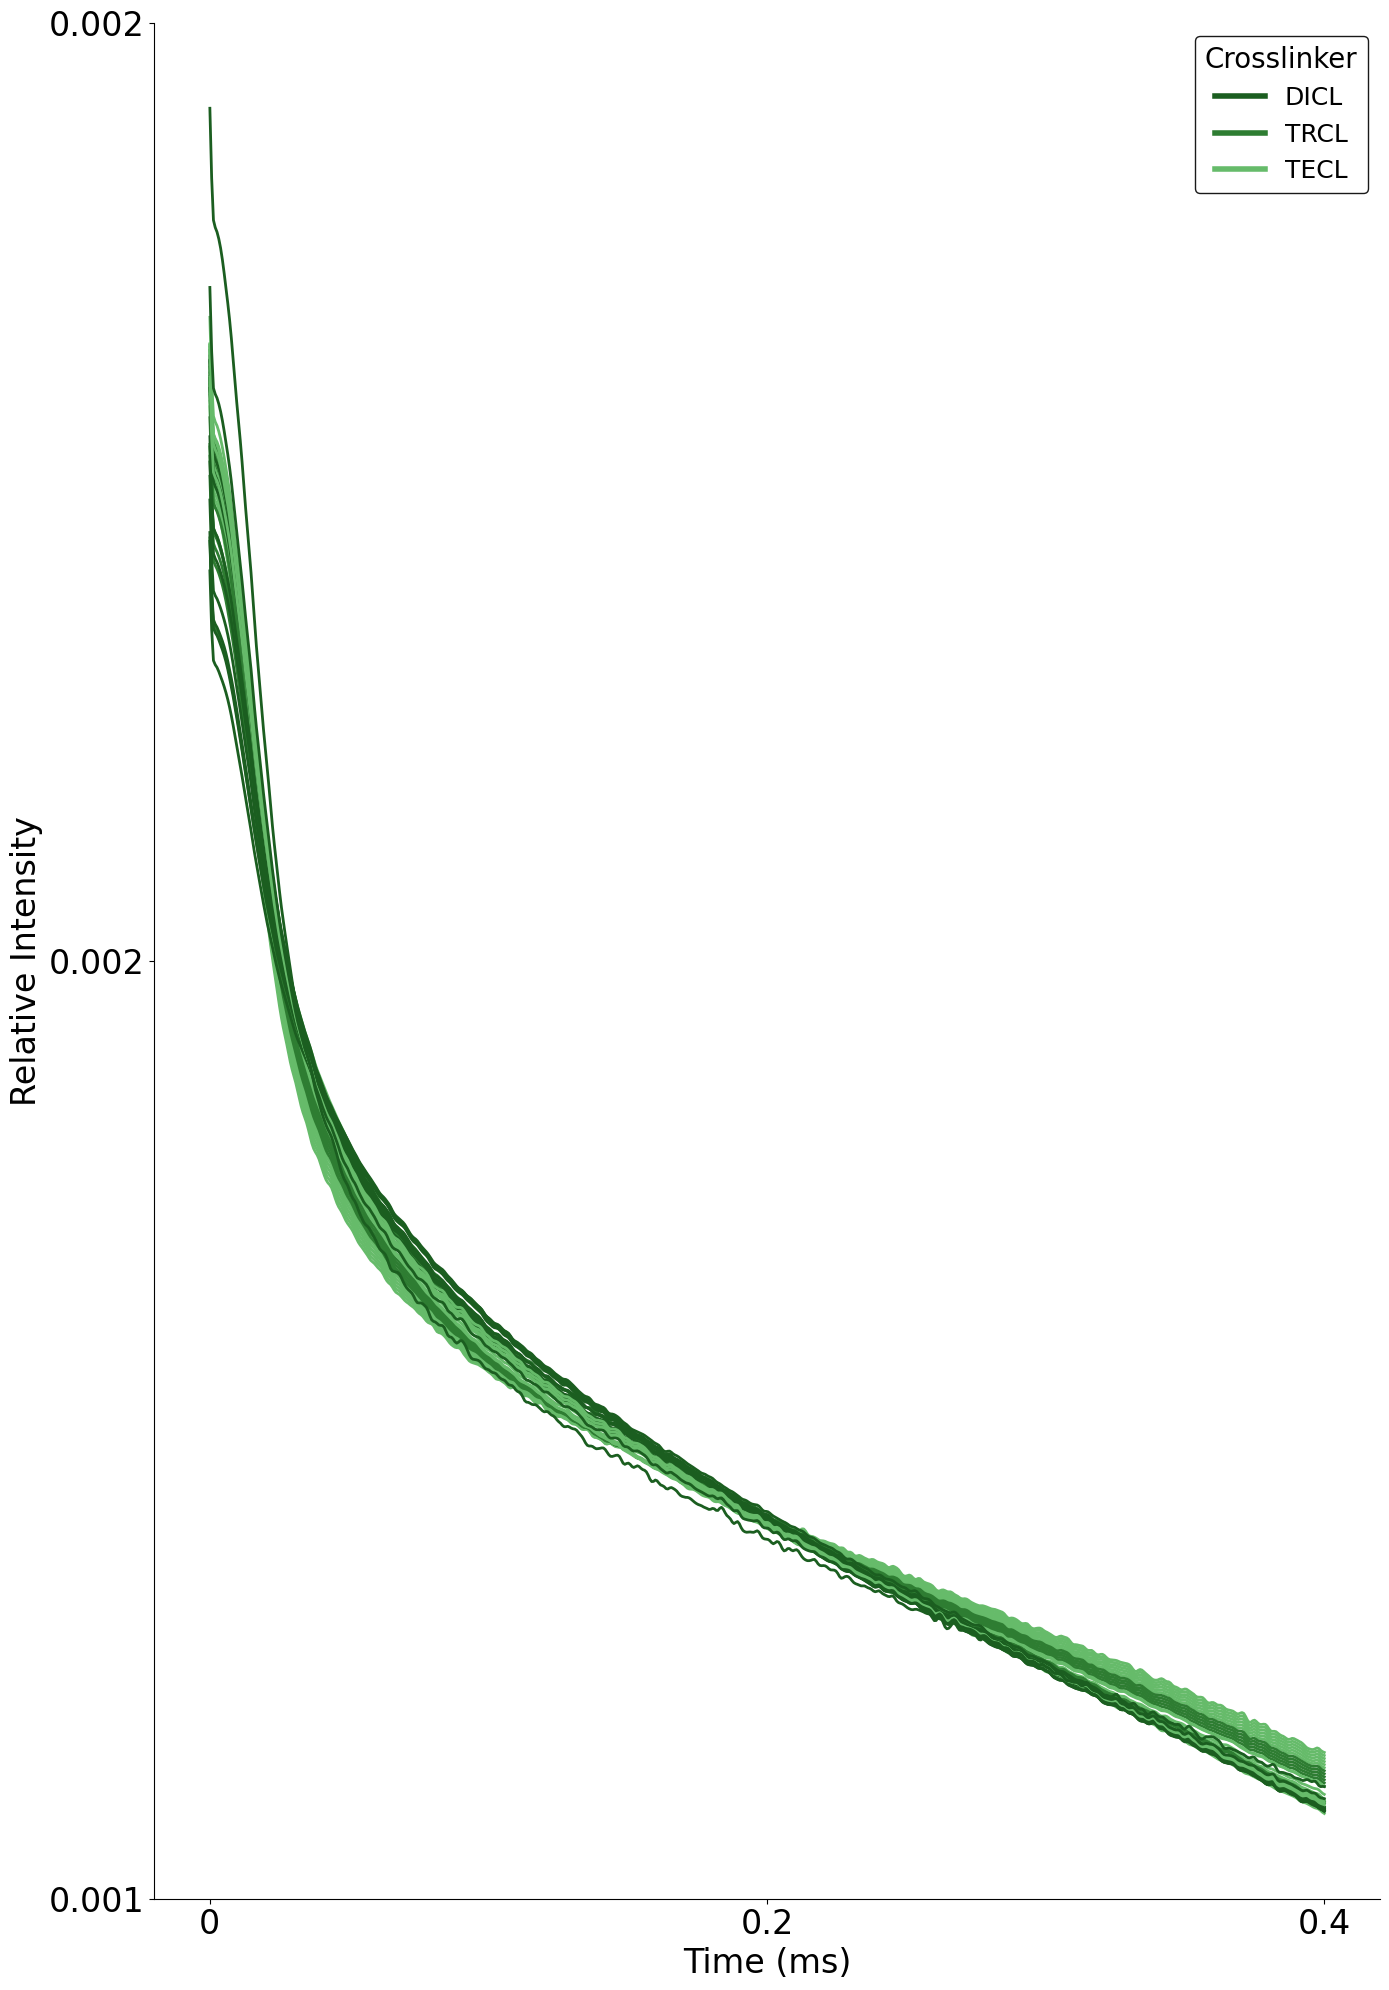

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from matplotlib.lines import Line2D

CSV_MSE = "Addwater_MSE_T2_Relative_Intensity_smoothed_44copolymers2.csv"

# =========================
# Load
# =========================
df = pd.read_csv(CSV_MSE)

name_col = df.columns[0]
df[name_col] = df[name_col].astype(str)
df = df.drop_duplicates(subset=name_col).reset_index(drop=True)

# =========================
# Time axis
# =========================
n = df.shape[1] - 1
time_ms = np.linspace(0, 0.4, n)

# =========================
# Crosslinker colors
# =========================
CROSSLINKER_ORDER = ["DICL", "TRCL", "TECL"]

color_map = {
    "DICL": "#1B5E20",
    "TRCL": "#2E7D32",
    "TECL": "#66BB6A",
    "OTHER": "#999999",
}

def get_crosslinker(label: str) -> str:
    s = str(label)
    s = re.sub(r'_\d+$', '', s)
    parts = s.split("_")

    for cl in CROSSLINKER_ORDER:
        if cl in parts:
            return cl

    return "OTHER"

# =========================
# Plot
# =========================
fig, ax = plt.subplots(figsize=(14, 20))

for _, row in df.iterrows():
    name = row.iloc[0]
    y = row.iloc[1:].values.astype(float)

    cl = get_crosslinker(name)
    color = color_map.get(cl, color_map["OTHER"])

    ax.plot(
        time_ms,
        y,
        lw=2,
        color=color
    )

# =========================
# Axis labels
# =========================
ax.set_xlabel("Time (ms)", fontsize=24)
ax.set_ylabel("Relative Intensity", fontsize=24)

# =========================
# Axis ticks
# =========================
ax.set_xticks([0.0, 0.2, 0.4])
ax.set_xticklabels(["0", "0.2", "0.4"], fontsize=24)

ymin, ymax = ax.get_ylim()
yt = [ymin, (ymin + ymax) / 2, ymax]

ax.set_yticks(yt)
ax.set_yticklabels(
    [f"{v:.3f}" for v in yt],
    fontsize=24
)

# =========================
# Style
# =========================
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# =========================
# Crosslinker legend
# =========================
legend_handles = [
    Line2D([0], [0], color=color_map["DICL"], lw=4, label="DICL"),
    Line2D([0], [0], color=color_map["TRCL"], lw=4, label="TRCL"),
    Line2D([0], [0], color=color_map["TECL"], lw=4, label="TECL"),
]

ax.legend(
    handles=legend_handles,
    title="Crosslinker",
    loc="upper right",
    fontsize=18,
    title_fontsize=20,
    frameon=True,
    framealpha=0.9,
    edgecolor="black"
)

# =========================
# Save
# =========================
plt.tight_layout()

plt.savefig(
    "Addwater_MSE_allcopolymers_crosslinker_legend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()